In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import numpy as np
from scipy import stats

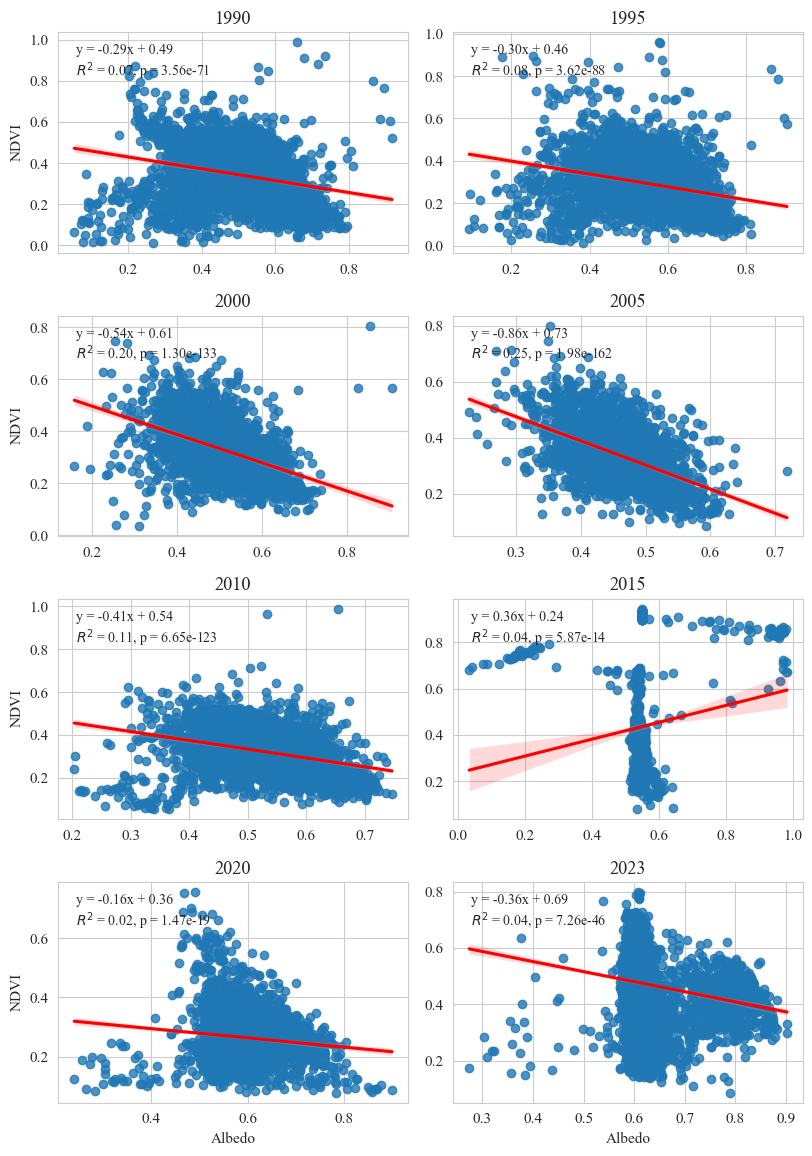

In [15]:
# Set up the figure size for A4 dimensions (210 mm x 297 mm)
plt.figure(figsize=(8.27, 11.69))  # A4 size in inches: 210 mm x 297 mm

# Set the font globally to Times New Roman, 11 pt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

# Get all CSV files in the directory (update the path as needed)
csv_files = glob.glob("F:/geodata/Desert/scatter_data/*.csv")

# Sort the files to maintain chronological order based on the year in the filename
csv_files.sort()

# Determine the number of rows needed based on the number of files
num_rows = (len(csv_files) + 1) // 2

# Iterate through the files and plot each one
for i, file in enumerate(csv_files):
    # Read the CSV file
    df = pd.read_csv(file)
    
    # Extract the year from the filename (assuming the year is the last 4 characters before '.csv')
    year = file[-8:-4]
    
    # Create a subplot for each file, 2 charts per row
    ax = plt.subplot(num_rows, 2, i + 1)
    
    # Plot the scatter plot with a fit line
    sns.regplot(x=df.iloc[:, 0], y=df.iloc[:, 1], scatter=True, line_kws={"color": "red"}, ax=ax)
    
    # Calculate the slope, intercept, R2, and p-value
    slope, intercept, r_value, p_value, std_err = stats.linregress(df.iloc[:, 0], df.iloc[:, 1])
    
    # Add the equation of the line, R2, and p-value to the plot
    ax.text(0.05, 0.95, f"y = {slope:.2f}x + {intercept:.2f}\n"
                        f"$R^2$ = {r_value**2:.2f}, p = {p_value:.2e}",
            transform=ax.transAxes, fontsize=10, verticalalignment='top')
    
    # Set the title to the extracted year
    plt.title(year)
    
    # Set Y-axis label to 'NDVI' only if it's in the first column
    if (i + 1) % 2 != 0:
        ax.set_ylabel('NDVI')
    else:
        ax.set_ylabel('')
    
    # Set X-axis label to 'Albedo' only if it's in the last row
    if i >= len(csv_files) - 2:
        ax.set_xlabel('Albedo')
    else:
        ax.set_xlabel('')

# Adjust the layout to prevent overlapping titles and labels
plt.tight_layout()

plt.savefig(r"F:\geodata\Desert\scatter_data\scatter_plot.svg")
# Show the plots
plt.show()